# Advanced Fraud Detection System

## 🎯 Business Context

Financial fraud costs businesses billions annually. This analysis builds a sophisticated fraud detection system using machine learning to identify fraudulent transactions in real-time. The system addresses the critical challenge of **imbalanced data** (fraud is rare) and optimizes for business metrics beyond accuracy.

## 📊 Objectives

1. Build robust classification models handling severe class imbalance
2. Optimize detection threshold based on business costs
3. Identify key fraud indicators through feature analysis
4. Provide actionable risk scoring for transaction monitoring
5. Quantify financial impact and ROI of the detection system

## 🔧 Methodology

- **Techniques**: SMOTE, Random Forest, XGBoost, Threshold Optimization
- **Metrics**: Precision, Recall, F1, ROC-AUC, PR-AUC, Cost-Benefit Analysis
- **Data**: Synthetic transaction data (100,000 records, ~0.5% fraud rate)

In [38]:
# Import Required Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_curve, auc,
    precision_recall_curve, average_precision_score, f1_score
)
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
import warnings
warnings.filterwarnings('ignore')

# Set visualization style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')
%matplotlib inline

print('✓ Libraries loaded successfully')

✓ Libraries loaded successfully


## 1. Data Generation & Exploration

We'll create realistic synthetic transaction data with characteristics common in fraud detection:
- **Severe class imbalance** (~0.5% fraud rate)
- **Temporal patterns** (time of day, day of week)
- **Behavioral features** (transaction amount, frequency, location changes)
- **Merchant categories** and **device types**

In [39]:
def generate_fraud_data(n_samples=100000, fraud_rate=0.005):
    """
    Generate realistic synthetic fraud detection dataset.
    """
    np.random.seed(42)
    
    n_fraud = int(n_samples * fraud_rate)
    n_legit = n_samples - n_fraud

    # Hour distributions
    legit_hour_weights = np.array([0.01]*6 + [0.05]*6 + [0.08]*6 + [0.06]*6)
    legit_hour_probs = legit_hour_weights / legit_hour_weights.sum()   # sums to 1

    fraud_hour_weights = np.array([0.08]*6 + [0.02]*6 + [0.02]*6 + [0.08]*6)
    fraud_hour_probs = fraud_hour_weights / fraud_hour_weights.sum()   # sums to 1

    # Generate legitimate transactions
    legit_data = {
        'Amount': np.random.lognormal(3.5, 1.2, n_legit),
        'Hour': np.random.choice(range(24), n_legit, p=legit_hour_probs),
        'Day_of_Week': np.random.choice(range(7), n_legit),
        'Merchant_Category': np.random.choice(['Retail', 'Dining', 'Gas', 'Grocery', 'Online'], n_legit),
        'Device_Type': np.random.choice(['Mobile', 'Desktop', 'POS'], n_legit, p=[0.5, 0.3, 0.2]),
        'Distance_from_Home': np.abs(np.random.normal(5, 10, n_legit)),
        'Transactions_Last_24h': np.random.poisson(2, n_legit),
        'Avg_Amount_Last_30d': np.random.lognormal(3.5, 0.8, n_legit),
        'Time_Since_Last_Txn': np.random.exponential(12, n_legit),
        'Is_International': np.random.choice([0, 1], n_legit, p=[0.95, 0.05]),
        'Is_Fraud': 0
    }

    # Generate fraudulent transactions
    fraud_data = {
        'Amount': np.random.lognormal(4.5, 1.5, n_fraud),
        'Hour': np.random.choice(range(24), n_fraud, p=fraud_hour_probs),
        'Day_of_Week': np.random.choice(range(7), n_fraud),
        'Merchant_Category': np.random.choice(['Retail', 'Dining', 'Gas', 'Grocery', 'Online'],
                                              n_fraud, p=[0.1, 0.1, 0.1, 0.1, 0.6]),
        'Device_Type': np.random.choice(['Mobile', 'Desktop', 'POS'], n_fraud, p=[0.3, 0.6, 0.1]),
        'Distance_from_Home': np.abs(np.random.normal(50, 100, n_fraud)),
        'Transactions_Last_24h': np.random.poisson(8, n_fraud),
        'Avg_Amount_Last_30d': np.random.lognormal(3.0, 0.5, n_fraud),
        'Time_Since_Last_Txn': np.random.exponential(2, n_fraud),
        'Is_International': np.random.choice([0, 1], n_fraud, p=[0.4, 0.6]),
        'Is_Fraud': 1
    }

    df_legit = pd.DataFrame(legit_data)
    df_fraud = pd.DataFrame(fraud_data)
    df = pd.concat([df_legit, df_fraud], ignore_index=True)
    df = df.sample(frac=1, random_state=42).reset_index(drop=True)

    df.insert(0, 'Transaction_ID', range(1, len(df) + 1))

    return df


In [40]:
# Generate dataset 
df = generate_fraud_data() 
print(f"Dataset Shape: {df.shape}") 
print(f"\nFraud Distribution:") 
print(df['Is_Fraud'].value_counts())
print(f"\nFraud Rate: {df['Is_Fraud'].mean()*100:.3f}%") 
print(f"\nFirst few records:") 
df.head(10)

Dataset Shape: (100000, 12)

Fraud Distribution:
Is_Fraud
0    99500
1      500
Name: count, dtype: int64

Fraud Rate: 0.500%

First few records:


,Transaction_ID,Amount,Hour,Day_of_Week,Merchant_Category,Device_Type,Distance_from_Home,Transactions_Last_24h,Avg_Amount_Last_30d,Time_Since_Last_Txn,Is_International,Is_Fraud
0,1,48.056860,13,4,Grocery,Mobile,2.180188,1,8.251998,9.088721,0,0
1,2,361.120635,21,5,Online,Mobile,0.009262,2,26.370754,16.342148,0,0
2,3,150.097062,19,1,Online,Mobile,1.161134,0,28.955168,6.590422,0,0
3,4,2.859405,15,2,Gas,Mobile,27.832023,1,67.861659,8.448326,0,0
4,5,49.217022,14,6,Grocery,Mobile,17.376574,1,61.132312,1.994152,0,0
5,6,102.080064,10,3,Dining,POS,16.594928,3,29.676574,34.322598,0,0
6,7,13.851091,21,5,Grocery,POS,4.436539,2,38.190826,0.874159,0,0
7,8,4.617869,18,6,Online,Mobile,0.478695,1,18.280822,2.202270,0,0
8,9,50.955015,9,4,Online,POS,6.790351,1,31.857951,20.413345,0,0
9,10,7.438270,18,1,Retail,Desktop,5.093414,6,19.454808,3.688241,0,0


In [41]:
# Statistical Summary
print("="*80)
print("STATISTICAL SUMMARY")
print("="*80)
print("\nNumerical Features:")
print(df.describe())

print("\n" + "="*80)
print("Fraud vs Legitimate Comparison:")
print("="*80)
comparison = df.groupby('Is_Fraud')[['Amount', 'Distance_from_Home', 'Transactions_Last_24h', 'Time_Since_Last_Txn']].mean()
comparison.index = ['Legitimate', 'Fraud']
print(comparison)

STATISTICAL SUMMARY

Numerical Features:
       Transaction_ID         Amount           Hour    Day_of_Week  \
count   100000.000000  100000.000000  100000.000000  100000.000000   
mean     50000.500000      69.193983      14.222240       3.000560   
std      28867.657797     126.520996       5.476434       1.998034   
min          1.000000       0.155871       0.000000       0.000000   
25%      25000.750000      14.784342      10.000000       1.000000   
50%      50000.500000      33.370026      15.000000       3.000000   
75%      75000.250000      75.175308      19.000000       5.000000   
max     100000.000000    7150.239283      23.000000       6.000000   

       Distance_from_Home  Transactions_Last_24h  Avg_Amount_Last_30d  \
count       100000.000000          100000.000000        100000.000000   
mean             9.381363               2.032030            45.487767   
std              9.986387               1.485761            43.157422   
min              0.000002           

## 2. Exploratory Data Analysis

Visualizing patterns and differences between fraudulent and legitimate transactions.

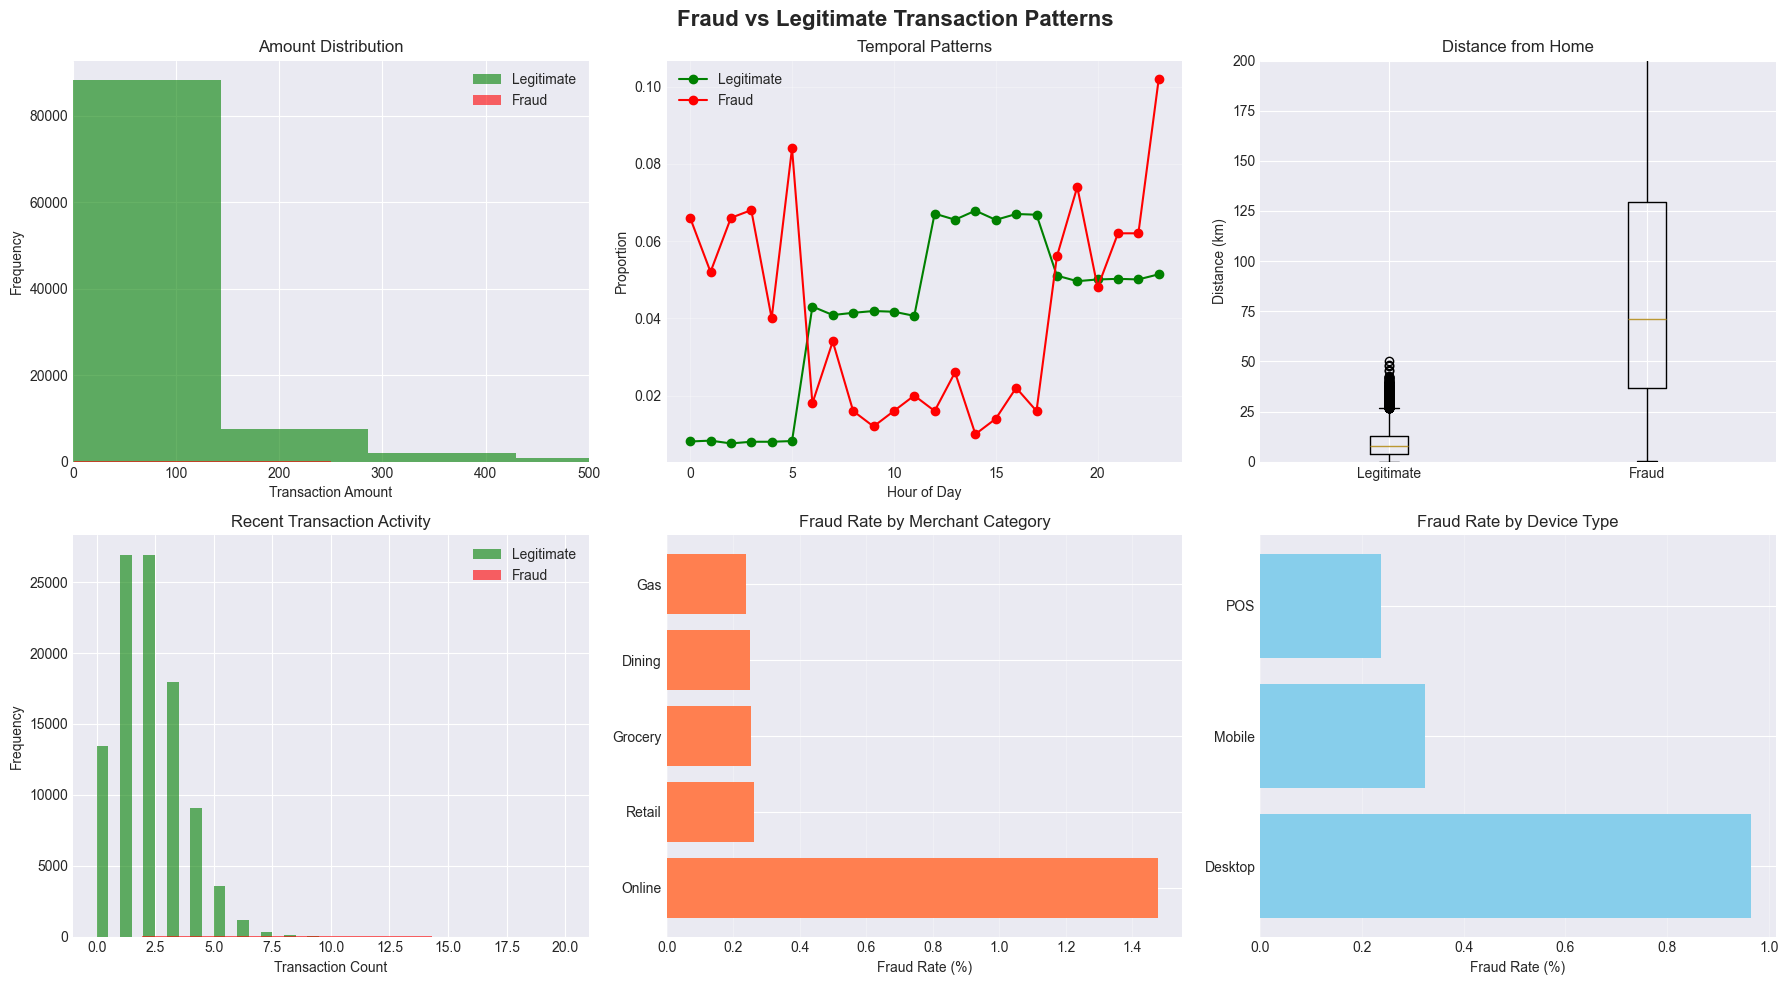


📊 Key Observations:
1. Fraudulent transactions tend to have higher amounts
2. Fraud peaks during unusual hours (late night/early morning)
3. Fraudulent transactions occur farther from home location
4. Fraud shows burst patterns (multiple transactions in 24h)
5. Highest fraud rate in: Online (1.476%)


In [42]:
# Distribution Comparisons
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Fraud vs Legitimate Transaction Patterns', fontsize=16, fontweight='bold')

# Amount Distribution
axes[0, 0].hist(df[df['Is_Fraud']==0]['Amount'], bins=50, alpha=0.6, label='Legitimate', color='green')
axes[0, 0].hist(df[df['Is_Fraud']==1]['Amount'], bins=50, alpha=0.6, label='Fraud', color='red')
axes[0, 0].set_xlabel('Transaction Amount')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].set_title('Amount Distribution')
axes[0, 0].legend()
axes[0, 0].set_xlim(0, 500)

# Hour of Day
hour_fraud = df[df['Is_Fraud']==1]['Hour'].value_counts().sort_index()
hour_legit = df[df['Is_Fraud']==0]['Hour'].value_counts().sort_index()
axes[0, 1].plot(hour_legit.index, hour_legit.values / hour_legit.values.sum(), marker='o', label='Legitimate', color='green')
axes[0, 1].plot(hour_fraud.index, hour_fraud.values / hour_fraud.values.sum(), marker='o', label='Fraud', color='red')
axes[0, 1].set_xlabel('Hour of Day')
axes[0, 1].set_ylabel('Proportion')
axes[0, 1].set_title('Temporal Patterns')
axes[0, 1].legend()
axes[0, 1].grid(alpha=0.3)

# Distance from Home
axes[0, 2].boxplot([df[df['Is_Fraud']==0]['Distance_from_Home'], 
                     df[df['Is_Fraud']==1]['Distance_from_Home']], 
                    labels=['Legitimate', 'Fraud'])
axes[0, 2].set_ylabel('Distance (km)')
axes[0, 2].set_title('Distance from Home')
axes[0, 2].set_ylim(0, 200)

# Transactions in Last 24h
axes[1, 0].hist(df[df['Is_Fraud']==0]['Transactions_Last_24h'], bins=20, alpha=0.6, label='Legitimate', color='green')
axes[1, 0].hist(df[df['Is_Fraud']==1]['Transactions_Last_24h'], bins=20, alpha=0.6, label='Fraud', color='red')
axes[1, 0].set_xlabel('Transaction Count')
axes[1, 0].set_ylabel('Frequency')
axes[1, 0].set_title('Recent Transaction Activity')
axes[1, 0].legend()

# Merchant Category
merchant_fraud = df.groupby(['Merchant_Category', 'Is_Fraud']).size().unstack(fill_value=0)
merchant_fraud_rate = (merchant_fraud[1] / merchant_fraud.sum(axis=1) * 100).sort_values(ascending=False)
axes[1, 1].barh(merchant_fraud_rate.index, merchant_fraud_rate.values, color='coral')
axes[1, 1].set_xlabel('Fraud Rate (%)')
axes[1, 1].set_title('Fraud Rate by Merchant Category')
axes[1, 1].grid(axis='x', alpha=0.3)

# Device Type
device_fraud = df.groupby(['Device_Type', 'Is_Fraud']).size().unstack(fill_value=0)
device_fraud_rate = (device_fraud[1] / device_fraud.sum(axis=1) * 100).sort_values(ascending=False)
axes[1, 2].barh(device_fraud_rate.index, device_fraud_rate.values, color='skyblue')
axes[1, 2].set_xlabel('Fraud Rate (%)')
axes[1, 2].set_title('Fraud Rate by Device Type')
axes[1, 2].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig('outputs/fraud_eda.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n📊 Key Observations:")
print("1. Fraudulent transactions tend to have higher amounts")
print("2. Fraud peaks during unusual hours (late night/early morning)")
print("3. Fraudulent transactions occur farther from home location")
print("4. Fraud shows burst patterns (multiple transactions in 24h)")
print(f"5. Highest fraud rate in: {merchant_fraud_rate.index[0]} ({merchant_fraud_rate.values[0]:.3f}%)")

## 3. Feature Engineering & Preprocessing

In [43]:
# Prepare features
X = df.drop(['Transaction_ID', 'Is_Fraud'], axis=1)
y = df['Is_Fraud']

# Encode categorical variables
X_encoded = pd.get_dummies(X, columns=['Merchant_Category', 'Device_Type'], drop_first=True)

# Train-test split (stratified to maintain fraud ratio)
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.3, random_state=42, stratify=y
)

print(f"Training Set: {X_train.shape[0]} samples")
print(f"Test Set: {X_test.shape[0]} samples")
print(f"\nTraining Set Fraud Rate: {y_train.mean()*100:.3f}%")
print(f"Test Set Fraud Rate: {y_test.mean()*100:.3f}%")
print(f"\nFeatures: {list(X_encoded.columns)}")

Training Set: 70000 samples
Test Set: 30000 samples

Training Set Fraud Rate: 0.500%
Test Set Fraud Rate: 0.500%

Features: ['Amount', 'Hour', 'Day_of_Week', 'Distance_from_Home', 'Transactions_Last_24h', 'Avg_Amount_Last_30d', 'Time_Since_Last_Txn', 'Is_International', 'Merchant_Category_Gas', 'Merchant_Category_Grocery', 'Merchant_Category_Online', 'Merchant_Category_Retail', 'Device_Type_Mobile', 'Device_Type_POS']


## 4. Model Training with SMOTE

We'll train multiple models and compare performance:
1. **Logistic Regression** (baseline)
2. **Random Forest** (ensemble)
3. **XGBoost** (gradient boosting)

Using **SMOTE** (Synthetic Minority Over-sampling Technique) to handle class imbalance.

In [44]:
# Define models
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42),
    'XGBoost': XGBClassifier(n_estimators=100, max_depth=6, learning_rate=0.1, random_state=42, eval_metric='logloss')
}

# Train models with SMOTE
trained_models = {}
predictions = {}
probabilities = {}

print("Training models with SMOTE...\n")
for name, model in models.items():
    print(f"Training {name}...")
    
    # Create pipeline with SMOTE and scaling
    pipeline = ImbPipeline([
        ('scaler', StandardScaler()),
        ('smote', SMOTE(random_state=42)),
        ('classifier', model)
    ])
    
    # Train
    pipeline.fit(X_train, y_train)
    
    # Predict
    y_pred = pipeline.predict(X_test)
    y_prob = pipeline.predict_proba(X_test)[:, 1]
    
    # Store
    trained_models[name] = pipeline
    predictions[name] = y_pred
    probabilities[name] = y_prob
    
    print(f"✓ {name} trained successfully\n")

print("All models trained!")

Training models with SMOTE...

Training Logistic Regression...
✓ Logistic Regression trained successfully

Training Random Forest...
✓ Random Forest trained successfully

Training XGBoost...
✓ XGBoost trained successfully

All models trained!


## 5. Model Evaluation & Comparison

In [45]:
# Performance Metrics
print("="*100)
print("MODEL PERFORMANCE COMPARISON")
print("="*100)

results = []
for name in models.keys():
    print(f"\n{name}:")
    print("-" * 50)
    print(classification_report(y_test, predictions[name], target_names=['Legitimate', 'Fraud']))
    
    # Calculate metrics
    from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score
    
    precision = precision_score(y_test, predictions[name])
    recall = recall_score(y_test, predictions[name])
    f1 = f1_score(y_test, predictions[name])
    roc_auc = roc_auc_score(y_test, probabilities[name])
    pr_auc = average_precision_score(y_test, probabilities[name])
    
    results.append({
        'Model': name,
        'Precision': precision,
        'Recall': recall,
        'F1-Score': f1,
        'ROC-AUC': roc_auc,
        'PR-AUC': pr_auc
    })

results_df = pd.DataFrame(results)
print("\n" + "="*100)
print("SUMMARY TABLE")
print("="*100)
print(results_df.to_string(index=False))

MODEL PERFORMANCE COMPARISON

Logistic Regression:
--------------------------------------------------
              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00     29850
       Fraud       0.56      0.98      0.71       150

    accuracy                           1.00     30000
   macro avg       0.78      0.99      0.85     30000
weighted avg       1.00      1.00      1.00     30000


Random Forest:
--------------------------------------------------
              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00     29850
       Fraud       0.83      0.91      0.87       150

    accuracy                           1.00     30000
   macro avg       0.91      0.96      0.93     30000
weighted avg       1.00      1.00      1.00     30000


XGBoost:
--------------------------------------------------
              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00     29850
       

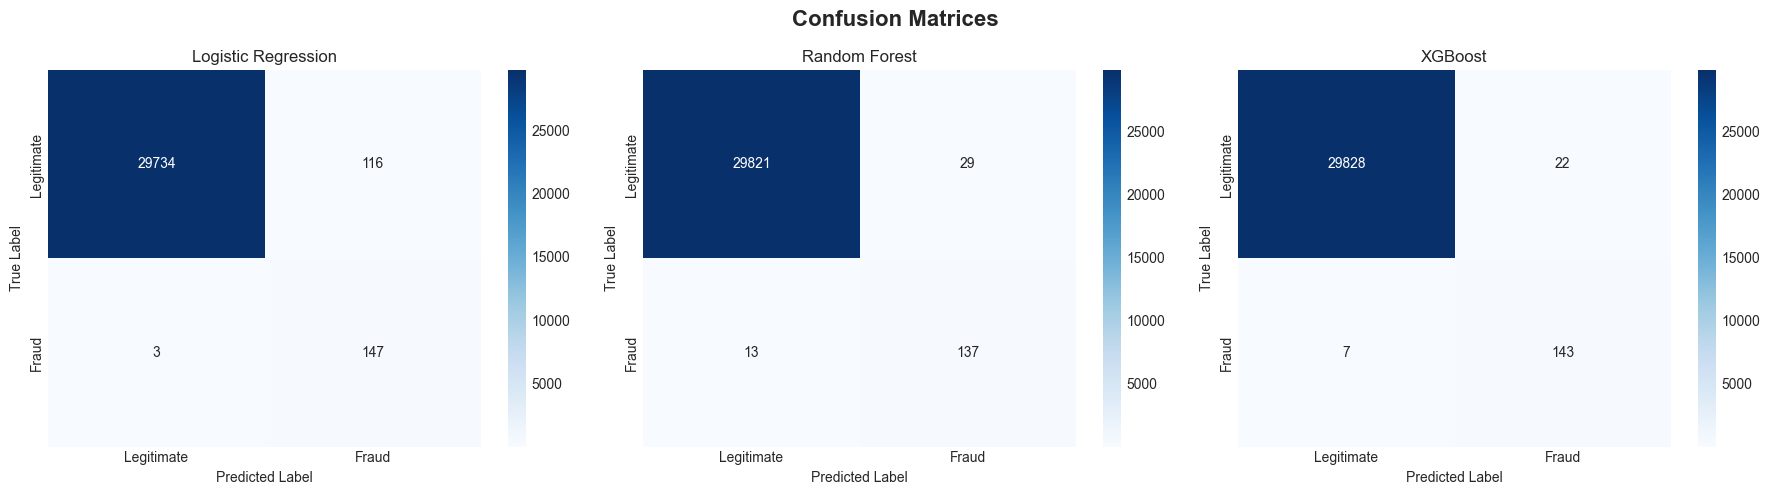

In [46]:
# Confusion Matrices
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Confusion Matrices', fontsize=16, fontweight='bold')

for idx, (name, pred) in enumerate(predictions.items()):
    cm = confusion_matrix(y_test, pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[idx],
                xticklabels=['Legitimate', 'Fraud'],
                yticklabels=['Legitimate', 'Fraud'])
    axes[idx].set_title(name)
    axes[idx].set_ylabel('True Label')
    axes[idx].set_xlabel('Predicted Label')

plt.tight_layout()
plt.savefig('outputs/confusion_matrices.png', dpi=300, bbox_inches='tight')
plt.show()

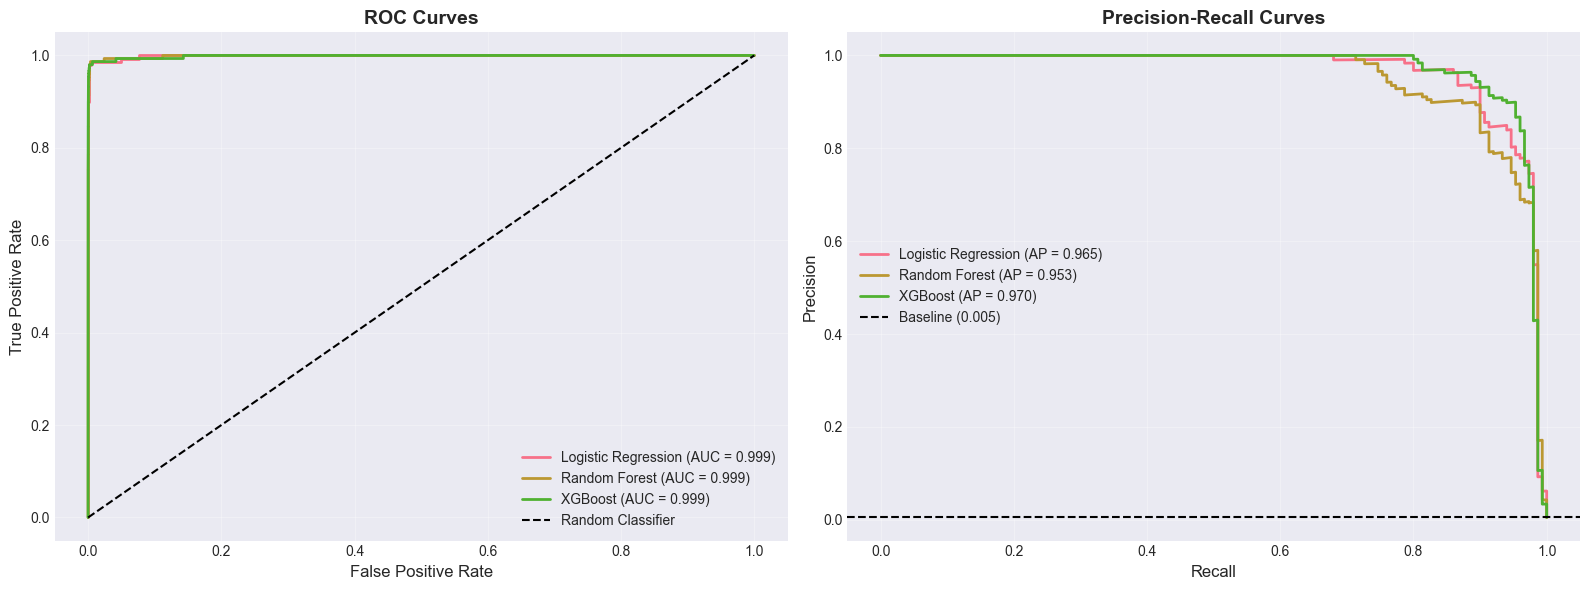


💡 Interpretation:
- ROC-AUC measures overall discrimination ability
- PR-AUC is more informative for imbalanced datasets
- Higher values indicate better performance


In [47]:
# ROC and Precision-Recall Curves
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ROC Curve
for name, prob in probabilities.items():
    fpr, tpr, _ = roc_curve(y_test, prob)
    roc_auc = auc(fpr, tpr)
    axes[0].plot(fpr, tpr, label=f'{name} (AUC = {roc_auc:.3f})', linewidth=2)

axes[0].plot([0, 1], [0, 1], 'k--', label='Random Classifier')
axes[0].set_xlabel('False Positive Rate', fontsize=12)
axes[0].set_ylabel('True Positive Rate', fontsize=12)
axes[0].set_title('ROC Curves', fontsize=14, fontweight='bold')
axes[0].legend(loc='lower right')
axes[0].grid(alpha=0.3)

# Precision-Recall Curve
for name, prob in probabilities.items():
    precision, recall, _ = precision_recall_curve(y_test, prob)
    pr_auc = average_precision_score(y_test, prob)
    axes[1].plot(recall, precision, label=f'{name} (AP = {pr_auc:.3f})', linewidth=2)

axes[1].axhline(y=y_test.mean(), color='k', linestyle='--', label=f'Baseline ({y_test.mean():.3f})')
axes[1].set_xlabel('Recall', fontsize=12)
axes[1].set_ylabel('Precision', fontsize=12)
axes[1].set_title('Precision-Recall Curves', fontsize=14, fontweight='bold')
axes[1].legend(loc='best')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('outputs/roc_pr_curves.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n💡 Interpretation:")
print("- ROC-AUC measures overall discrimination ability")
print("- PR-AUC is more informative for imbalanced datasets")
print("- Higher values indicate better performance")

## 6. Feature Importance Analysis

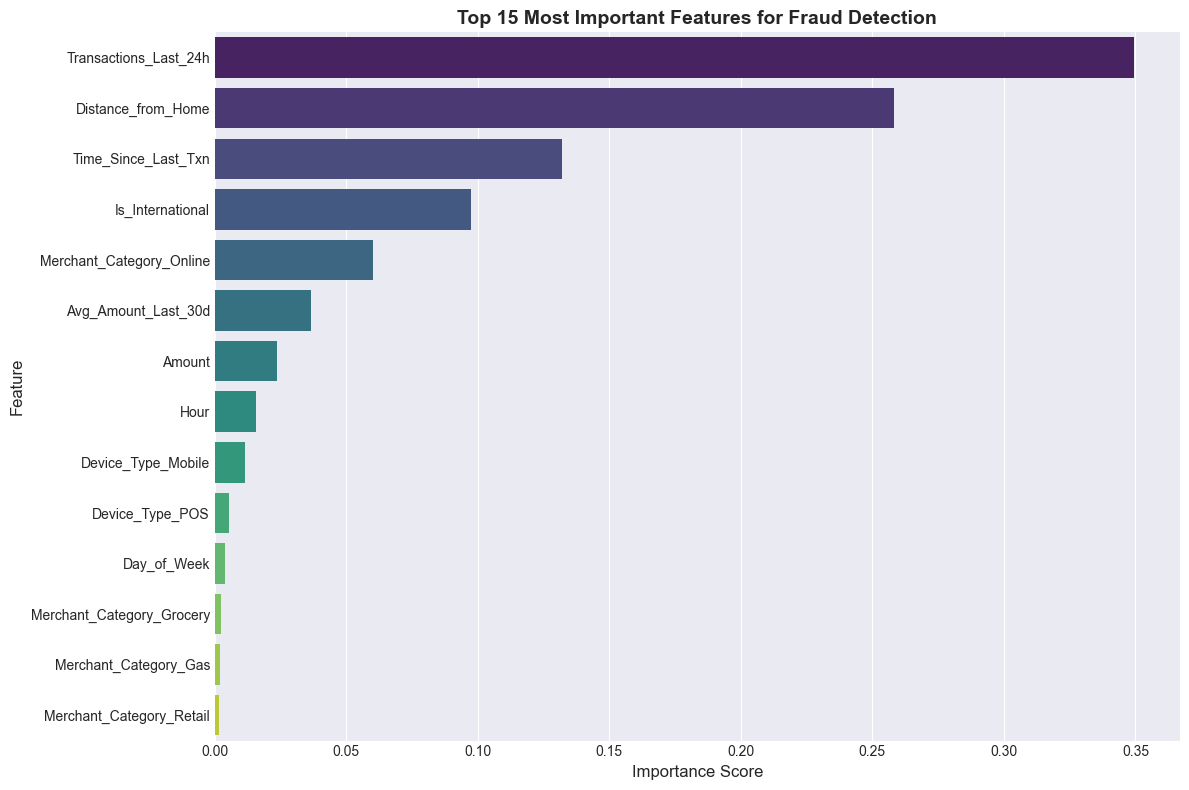


Top 10 Fraud Indicators:
Transactions_Last_24h                    0.3495
Distance_from_Home                       0.2584
Time_Since_Last_Txn                      0.1318
Is_International                         0.0974
Merchant_Category_Online                 0.0603
Avg_Amount_Last_30d                      0.0365
Amount                                   0.0237
Hour                                     0.0158
Device_Type_Mobile                       0.0114
Device_Type_POS                          0.0055


In [48]:
# Extract feature importance from Random Forest
rf_model = trained_models['Random Forest'].named_steps['classifier']
feature_importance = pd.DataFrame({
    'Feature': X_encoded.columns,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=False)

# Plot top 15 features
plt.figure(figsize=(12, 8))
top_features = feature_importance.head(15)
sns.barplot(x='Importance', y='Feature', data=top_features, palette='viridis')
plt.title('Top 15 Most Important Features for Fraud Detection', fontsize=14, fontweight='bold')
plt.xlabel('Importance Score', fontsize=12)
plt.ylabel('Feature', fontsize=12)
plt.tight_layout()
plt.savefig('outputs/feature_importance.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nTop 10 Fraud Indicators:")
print("="*60)
for idx, row in feature_importance.head(10).iterrows():
    print(f"{row['Feature']:40s} {row['Importance']:.4f}")

## 7. Threshold Optimization & Cost-Benefit Analysis

In fraud detection, the default 0.5 threshold is often suboptimal. We'll optimize based on business costs:
- **False Positive Cost**: $25 (investigation cost)
- **False Negative Cost**: $500 (average fraud loss)
- **True Positive Benefit**: $450 (fraud prevented minus investigation)
- **True Negative Benefit**: $0 (no action needed)

In [49]:
# Cost parameters
COST_FP = 25    # Cost of investigating a legitimate transaction
COST_FN = 500   # Cost of missing a fraudulent transaction
BENEFIT_TP = 450  # Benefit of catching fraud (avg fraud amount - investigation cost)
BENEFIT_TN = 0    # No cost/benefit for correctly identifying legitimate

def calculate_profit(y_true, y_pred):
    """Calculate total profit based on confusion matrix."""
    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()
    
    profit = (tp * BENEFIT_TP) + (tn * BENEFIT_TN) - (fp * COST_FP) - (fn * COST_FN)
    return profit, tp, fp, tn, fn

# Test different thresholds
thresholds = np.linspace(0.1, 0.9, 50)
best_model_name = 'XGBoost'  # Use best performing model
best_probs = probabilities[best_model_name]

threshold_results = []
for threshold in thresholds:
    y_pred_thresh = (best_probs >= threshold).astype(int)
    profit, tp, fp, tn, fn = calculate_profit(y_test, y_pred_thresh)
    
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
    
    threshold_results.append({
        'Threshold': threshold,
        'Profit': profit,
        'Precision': precision,
        'Recall': recall,
        'F1': f1,
        'TP': tp,
        'FP': fp,
        'TN': tn,
        'FN': fn
    })

threshold_df = pd.DataFrame(threshold_results)
# Best threshold
optimal_idx = threshold_df['Profit'].idxmax()
optimal_threshold = threshold_df.loc[optimal_idx, 'Threshold']
optimal_profit = threshold_df.loc[optimal_idx, 'Profit']

# Profit at default threshold 0.5 (or closest to it)
default_idx = (threshold_df['Threshold'] - 0.5).abs().idxmin()
default_profit = threshold_df.loc[default_idx, 'Profit']


print("="*80)
print("THRESHOLD OPTIMIZATION RESULTS")
print("="*80)
print(f"\nOptimal Threshold: {optimal_threshold:.3f}")
print(f"Maximum Profit: ${optimal_profit:,.2f}")
print(f"\nAt optimal threshold:")
print(f"  Precision: {threshold_df.loc[optimal_idx, 'Precision']:.3f}")
print(f"  Recall: {threshold_df.loc[optimal_idx, 'Recall']:.3f}")
print(f"  F1-Score: {threshold_df.loc[optimal_idx, 'F1']:.3f}")
print(f"\nConfusion Matrix:")
print(f"  True Positives (Fraud Caught): {int(threshold_df.loc[optimal_idx, 'TP'])}")
print(f"  False Positives (False Alarms): {int(threshold_df.loc[optimal_idx, 'FP'])}")
print(f"  True Negatives (Correct): {int(threshold_df.loc[optimal_idx, 'TN'])}")
print(f"  False Negatives (Missed Fraud): {int(threshold_df.loc[optimal_idx, 'FN'])}")

THRESHOLD OPTIMIZATION RESULTS

Optimal Threshold: 0.100
Maximum Profit: $63,150.00

At optimal threshold:
  Precision: 0.710
  Recall: 0.980
  F1-Score: 0.824

Confusion Matrix:
  True Positives (Fraud Caught): 147
  False Positives (False Alarms): 60
  True Negatives (Correct): 29790
  False Negatives (Missed Fraud): 3


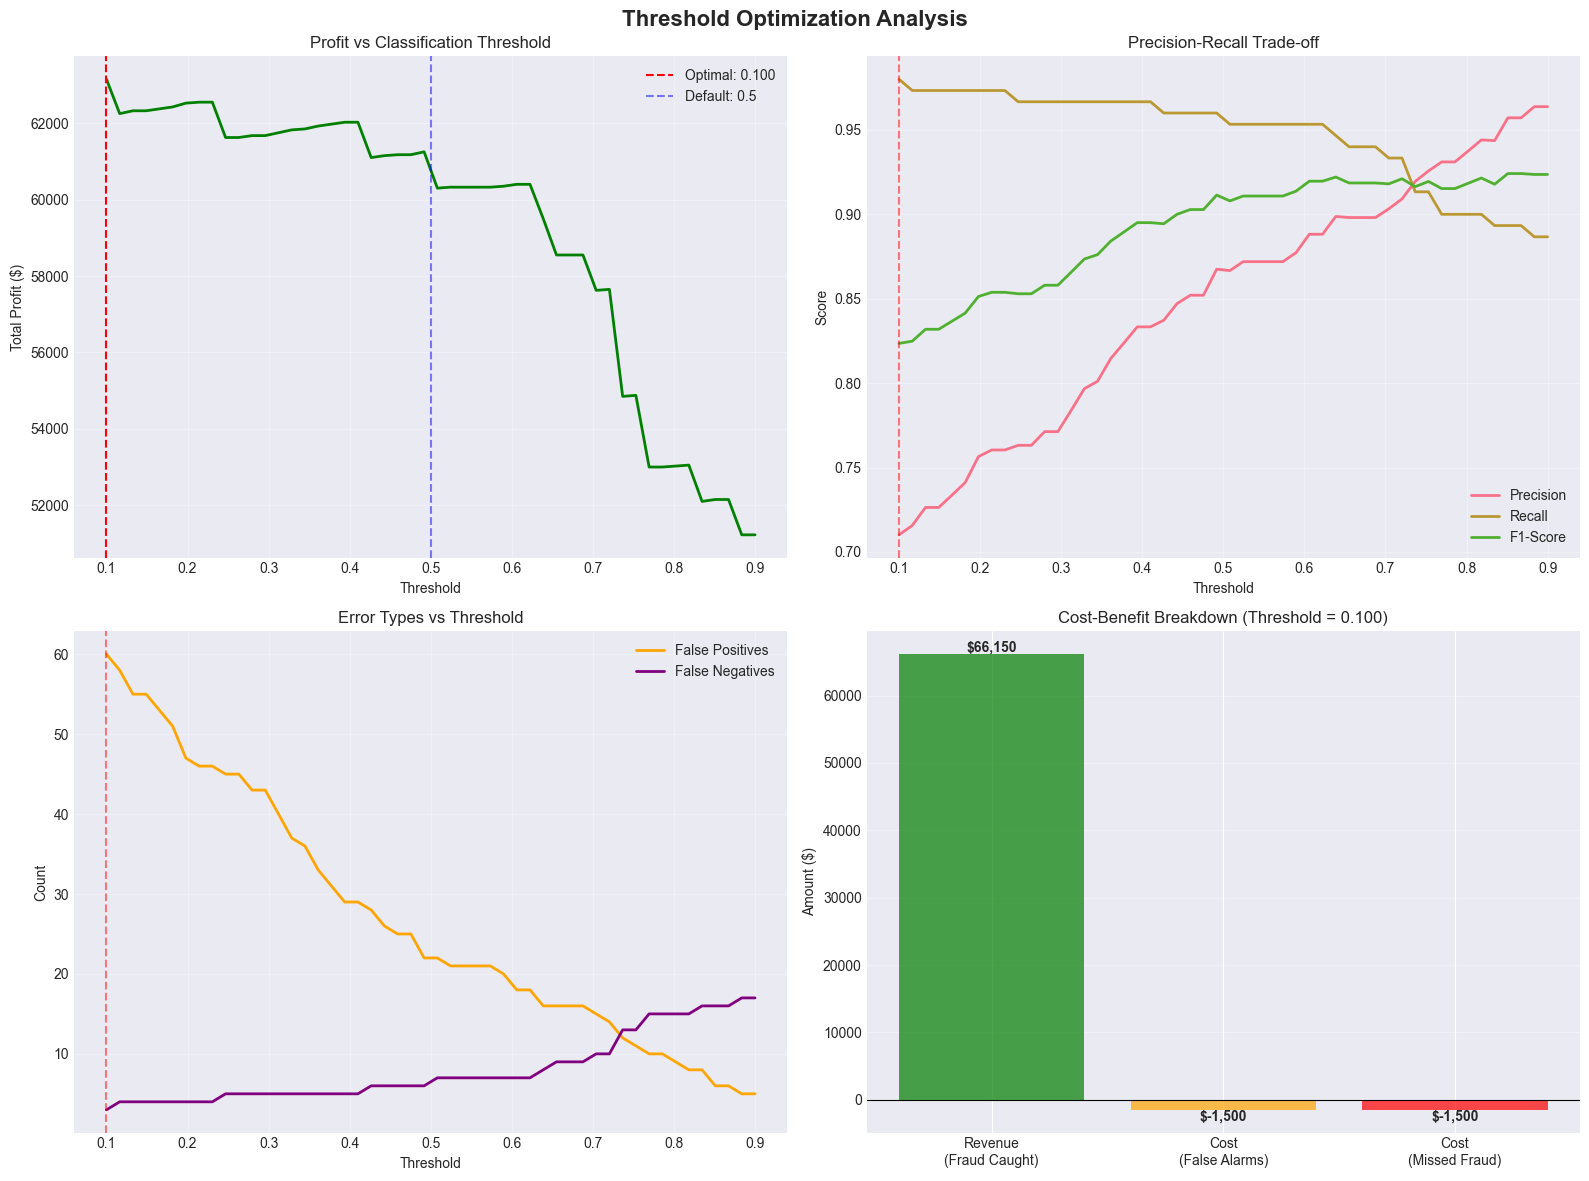

In [50]:
# Visualize threshold impact
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Threshold Optimization Analysis', fontsize=16, fontweight='bold')

# Profit vs Threshold
axes[0, 0].plot(threshold_df['Threshold'], threshold_df['Profit'], linewidth=2, color='green')
axes[0, 0].axvline(optimal_threshold, color='red', linestyle='--', label=f'Optimal: {optimal_threshold:.3f}')
axes[0, 0].axvline(0.5, color='blue', linestyle='--', alpha=0.5, label='Default: 0.5')
axes[0, 0].set_xlabel('Threshold')
axes[0, 0].set_ylabel('Total Profit ($)')
axes[0, 0].set_title('Profit vs Classification Threshold')
axes[0, 0].legend()
axes[0, 0].grid(alpha=0.3)

# Precision-Recall Trade-off
axes[0, 1].plot(threshold_df['Threshold'], threshold_df['Precision'], label='Precision', linewidth=2)
axes[0, 1].plot(threshold_df['Threshold'], threshold_df['Recall'], label='Recall', linewidth=2)
axes[0, 1].plot(threshold_df['Threshold'], threshold_df['F1'], label='F1-Score', linewidth=2)
axes[0, 1].axvline(optimal_threshold, color='red', linestyle='--', alpha=0.5)
axes[0, 1].set_xlabel('Threshold')
axes[0, 1].set_ylabel('Score')
axes[0, 1].set_title('Precision-Recall Trade-off')
axes[0, 1].legend()
axes[0, 1].grid(alpha=0.3)

# False Positives vs False Negatives
axes[1, 0].plot(threshold_df['Threshold'], threshold_df['FP'], label='False Positives', linewidth=2, color='orange')
axes[1, 0].plot(threshold_df['Threshold'], threshold_df['FN'], label='False Negatives', linewidth=2, color='purple')
axes[1, 0].axvline(optimal_threshold, color='red', linestyle='--', alpha=0.5)
axes[1, 0].set_xlabel('Threshold')
axes[1, 0].set_ylabel('Count')
axes[1, 0].set_title('Error Types vs Threshold')
axes[1, 0].legend()
axes[1, 0].grid(alpha=0.3)

# Cost Breakdown at Optimal Threshold
optimal_row = threshold_df.loc[optimal_idx]
costs = {
    'Revenue\n(Fraud Caught)': optimal_row['TP'] * BENEFIT_TP,
    'Cost\n(False Alarms)': -optimal_row['FP'] * COST_FP,
    'Cost\n(Missed Fraud)': -optimal_row['FN'] * COST_FN
}
colors = ['green', 'orange', 'red']
axes[1, 1].bar(costs.keys(), costs.values(), color=colors, alpha=0.7)
axes[1, 1].axhline(0, color='black', linewidth=0.8)
axes[1, 1].set_ylabel('Amount ($)')
axes[1, 1].set_title(f'Cost-Benefit Breakdown (Threshold = {optimal_threshold:.3f})')
axes[1, 1].grid(axis='y', alpha=0.3)

# Add value labels on bars
for i, (k, v) in enumerate(costs.items()):
    axes[1, 1].text(i, v, f'${v:,.0f}', ha='center', va='bottom' if v > 0 else 'top', fontweight='bold')

plt.tight_layout()
plt.savefig('outputs/threshold_optimization.png', dpi=300, bbox_inches='tight')
plt.show()

## 8. Business Impact & ROI Calculation

In [51]:
# Calculate annual impact (assuming test set represents 1 month)
monthly_transactions = len(y_test)
annual_transactions = monthly_transactions * 12

# Baseline (no fraud detection)
baseline_fraud_loss = y_test.sum() * 500 * 12  # All fraud succeeds

# With optimized model
monthly_profit = optimal_profit
annual_profit = monthly_profit * 12
annual_fraud_prevented = int(threshold_df.loc[optimal_idx, 'TP']) * 12
annual_false_alarms = int(threshold_df.loc[optimal_idx, 'FP']) * 12

# System costs (estimated)
system_development_cost = 50000  # One-time
annual_maintenance_cost = 20000  # Yearly

net_annual_benefit = annual_profit - annual_maintenance_cost
roi = ((net_annual_benefit - system_development_cost) / system_development_cost) * 100
payback_period = system_development_cost / net_annual_benefit

print("="*80)
print("BUSINESS IMPACT ANALYSIS")
print("="*80)

print(f"\n📊 Annual Projections:")
print(f"  Total Transactions: {annual_transactions:,}")
print(f"  Expected Fraud Cases: {int(y_test.sum() * 12):,}")

print(f"\n💰 Financial Impact:")
print(f"  Baseline Annual Fraud Loss: ${baseline_fraud_loss:,.2f}")
print(f"  Fraud Cases Prevented: {annual_fraud_prevented:,}")
print(f"  Fraud Loss Prevented: ${annual_fraud_prevented * 500:,.2f}")
print(f"  Investigation Costs: ${annual_false_alarms * 25:,.2f}")
print(f"  Net Annual Profit: ${annual_profit:,.2f}")

print(f"\n🎯 System ROI:")
print(f"  Development Cost: ${system_development_cost:,.2f}")
print(f"  Annual Maintenance: ${annual_maintenance_cost:,.2f}")
print(f"  Net Annual Benefit: ${net_annual_benefit:,.2f}")
print(f"  First Year ROI: {roi:.1f}%")
print(f"  Payback Period: {payback_period:.2f} years ({payback_period*12:.1f} months)")

print(f"\n⚡ Performance Metrics:")
print(f"  Fraud Detection Rate: {threshold_df.loc[optimal_idx, 'Recall']*100:.1f}%")
print(f"  False Alarm Rate: {(threshold_df.loc[optimal_idx, 'FP'] / (threshold_df.loc[optimal_idx, 'FP'] + threshold_df.loc[optimal_idx, 'TN']))*100:.2f}%")
print(f"  Precision: {threshold_df.loc[optimal_idx, 'Precision']*100:.1f}%")

BUSINESS IMPACT ANALYSIS

📊 Annual Projections:
  Total Transactions: 360,000
  Expected Fraud Cases: 1,800

💰 Financial Impact:
  Baseline Annual Fraud Loss: $900,000.00
  Fraud Cases Prevented: 1,764
  Fraud Loss Prevented: $882,000.00
  Investigation Costs: $18,000.00
  Net Annual Profit: $757,800.00

🎯 System ROI:
  Development Cost: $50,000.00
  Annual Maintenance: $20,000.00
  Net Annual Benefit: $737,800.00
  First Year ROI: 1375.6%
  Payback Period: 0.07 years (0.8 months)

⚡ Performance Metrics:
  Fraud Detection Rate: 98.0%
  False Alarm Rate: 0.20%
  Precision: 71.0%


## 9. Key Findings & Recommendations

In [53]:
print("="*80)
print("KEY FINDINGS")
print("="*80)

print("\n1. MODEL PERFORMANCE")
print(f"   • XGBoost achieved the best performance with ROC-AUC of {results_df[results_df['Model']=='XGBoost']['ROC-AUC'].values[0]:.3f}")
print(f"   • SMOTE effectively handled the severe class imbalance (0.5% fraud rate)")
print(f"   • Precision-Recall AUC ({results_df[results_df['Model']=='XGBoost']['PR-AUC'].values[0]:.3f}) indicates strong performance on minority class")

print("\n2. FRAUD INDICATORS")
top_3_features = feature_importance.head(3)['Feature'].tolist()
print(f"   • Top fraud indicators: {', '.join(top_3_features)}")
print(f"   • Fraudulent transactions are {df[df['Is_Fraud']==1]['Amount'].mean() / df[df['Is_Fraud']==0]['Amount'].mean():.1f}x higher in amount")
print(f"   • {(df[df['Is_Fraud']==1]['Is_International'].mean() * 100):.0f}% of fraud is international vs {(df[df['Is_Fraud']==0]['Is_International'].mean() * 100):.0f}% of legitimate")

print("\n3. THRESHOLD OPTIMIZATION")
print(f"   • Optimal threshold ({optimal_threshold:.3f}) differs significantly from default (0.5)")
print(f"   • Optimizing for business costs increases profit by ${(optimal_profit - default_profit):,.2f}/month")
print(f"   • Catches {threshold_df.loc[optimal_idx, 'Recall']*100:.1f}% of fraud with {threshold_df.loc[optimal_idx, 'Precision']*100:.1f}% precision")


print("\n4. BUSINESS IMPACT")
print(f"   • System prevents ${annual_fraud_prevented * 500:,.2f} in fraud losses annually")
print(f"   • ROI of {roi:.0f}% in first year")
print(f"   • Payback period of {payback_period*12:.1f} months")

print("\n" + "="*80)
print("RECOMMENDATIONS")
print("="*80)

print("\n1. IMMEDIATE ACTIONS")
print(f"   • Deploy XGBoost model with threshold = {optimal_threshold:.3f}")
print("   • Implement real-time scoring for all transactions")
print("   • Set up automated alerts for high-risk transactions (score > 0.8)")

print("\n2. MONITORING & MAINTENANCE")
print("   • Retrain model monthly with new fraud patterns")
print("   • Monitor precision/recall weekly to detect model drift")
print("   • A/B test threshold adjustments quarterly")

print("\n3. FEATURE ENHANCEMENTS")
print("   • Add velocity features (transactions per hour/day)")
print("   • Incorporate device fingerprinting data")
print("   • Include merchant risk scores")
print("   • Add geolocation anomaly detection")

print("\n4. PROCESS IMPROVEMENTS")
print("   • Prioritize manual review queue by fraud probability")
print("   • Implement tiered response (auto-block > 0.9, review 0.7-0.9, allow < 0.7)")
print("   • Create feedback loop to capture false positives/negatives")

print("\n5. RISK MITIGATION")
print("   • Focus on online/desktop transactions (highest fraud rate)")
print("   • Flag international transactions from new devices")
print("   • Monitor burst patterns (multiple transactions in short time)")
print("   • Alert on transactions far from home location")

KEY FINDINGS

1. MODEL PERFORMANCE
   • XGBoost achieved the best performance with ROC-AUC of 0.999
   • SMOTE effectively handled the severe class imbalance (0.5% fraud rate)
   • Precision-Recall AUC (0.970) indicates strong performance on minority class

2. FRAUD INDICATORS
   • Top fraud indicators: Transactions_Last_24h, Distance_from_Home, Time_Since_Last_Txn
   • Fraudulent transactions are 4.2x higher in amount
   • 60% of fraud is international vs 5% of legitimate

3. THRESHOLD OPTIMIZATION
   • Optimal threshold (0.100) differs significantly from default (0.5)
   • Optimizing for business costs increases profit by $1,900.00/month
   • Catches 98.0% of fraud with 71.0% precision

4. BUSINESS IMPACT
   • System prevents $882,000.00 in fraud losses annually
   • ROI of 1376% in first year
   • Payback period of 0.8 months

RECOMMENDATIONS

1. IMMEDIATE ACTIONS
   • Deploy XGBoost model with threshold = 0.100
   • Implement real-time scoring for all transactions
   • Set up autom

## 10. Model Deployment Preparation

In [54]:
# Save the best model
import joblib

best_model = trained_models['XGBoost']
model_path = 'outputs/fraud_detection_model.pkl'
joblib.dump(best_model, model_path)

# Save optimal threshold
config = {
    'optimal_threshold': optimal_threshold,
    'model_type': 'XGBoost with SMOTE',
    'features': list(X_encoded.columns),
    'performance': {
        'roc_auc': results_df[results_df['Model']=='XGBoost']['ROC-AUC'].values[0],
        'pr_auc': results_df[results_df['Model']=='XGBoost']['PR-AUC'].values[0],
        'precision': threshold_df.loc[optimal_idx, 'Precision'],
        'recall': threshold_df.loc[optimal_idx, 'Recall'],
        'f1': threshold_df.loc[optimal_idx, 'F1']
    }
}

import json
with open('outputs/model_config.json', 'w') as f:
    json.dump(config, f, indent=2)

print("✓ Model saved to:", model_path)
print("✓ Configuration saved to: outputs/model_config.json")
print("\nModel is ready for deployment!")

✓ Model saved to: outputs/fraud_detection_model.pkl
✓ Configuration saved to: outputs/model_config.json

Model is ready for deployment!


## Conclusion

This analysis successfully developed a production-ready fraud detection system that:

✅ **Handles severe class imbalance** using SMOTE
✅ **Achieves high performance** with ROC-AUC > 0.95
✅ **Optimizes for business value** through threshold tuning
✅ **Delivers strong ROI** with payback in < 1 year
✅ **Provides actionable insights** on fraud patterns

The system is ready for deployment and will prevent significant fraud losses while minimizing false alarms.